# Minilab 6: Neural Network Regression
**Rizaldy Utomo**  
`rutomo@andrew.cmu.edu`

- This notebook uses the Ames-style housing dataset from Minilab 3.
- The goal is to compare a Random Forest regressor with a neural-network regressor on the same train/test split.
- The primary metric is **MAPE**, with RMSE, MAE, and R-squared as supporting metrics.
- The best tuned neural network in this notebook is the **three-layer model `(100, 50, 25)` with learning rate `0.01`**, which reaches **11.56% MAPE**.


## Setup and Reproducibility


In [1]:
import warnings
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DATA_URL = "https://www.dropbox.com/scl/fi/yis5zpl35tyn2r3z4d7uf/real_estate_market_data.csv?rlkey=oa1106yj6knt6w1oufogdpequ&st=571k3go0&dl=1"

BASE_DIR = Path(".")
if not Path("brief_from canvas.md").exists() and Path("MiniLab/W11/brief_from canvas.md").exists():
    BASE_DIR = Path("MiniLab/W11")

IMG_DIR = BASE_DIR / "img"
IMG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

pd.set_option("display.max_columns", 25)


## Helper Functions


In [2]:
def save_and_show(fig, filename):
    output_path = IMG_DIR / filename
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def evaluate_regression(name, y_true, y_pred, train_seconds=None, extra=None):
    result = {
        "Model": name,
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R-squared": r2_score(y_true, y_pred),
    }
    if train_seconds is not None:
        result["Train Time (s)"] = train_seconds
    if extra:
        result.update(extra)
    return result


def count_mlp_parameters(input_dim, hidden_layers):
    layer_sizes = [input_dim, *hidden_layers, 1]
    total = 0
    for i in range(len(layer_sizes) - 1):
        total += (layer_sizes[i] + 1) * layer_sizes[i + 1]
    return total


def make_nn_model(hidden_layers, max_iter=500, learning_rate_init=0.001, early_stopping=True):
    regressor = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=early_stopping,
    )
    return TransformedTargetRegressor(
        regressor=regressor,
        transformer=StandardScaler(),
    )


## Load the Housing Data


In [3]:
data = pd.read_csv(DATA_URL)

print(f"Dataset shape: {data.shape}")
display(data.head())
display(data["Sale_Price"].describe().to_frame(name="Sale_Price"))

missing_summary = (
    data.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame(name="Missing Values")
)
print("Columns with missing values:")
display(missing_summary)


Dataset shape: (2829, 74)


,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,...,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,0,No_Pool,No_Fence,NaN,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,...,0,No_Pool,Minimum_Privacy,NaN,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,0,No_Pool,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,...,0,No_Pool,No_Fence,NaN,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,...,0,No_Pool,Minimum_Privacy,NaN,0,3,2010,WD,Normal,189900,-93.638933,42.060899


,Sale_Price
count,2829.000000
mean,180599.798515
std,80026.784594
min,12789.000000
25%,129000.000000
50%,160000.000000
75%,213250.000000
max,755000.000000


Columns with missing values:


,Missing Values
Misc_Feature,2730
Mas_Vnr_Type,1711


## Light EDA

This dataset mixes numeric and categorical variables, so we need both plots and encoding before modeling.
I kept the EDA short and focused on the target and two simple housing patterns from Minilab 3.


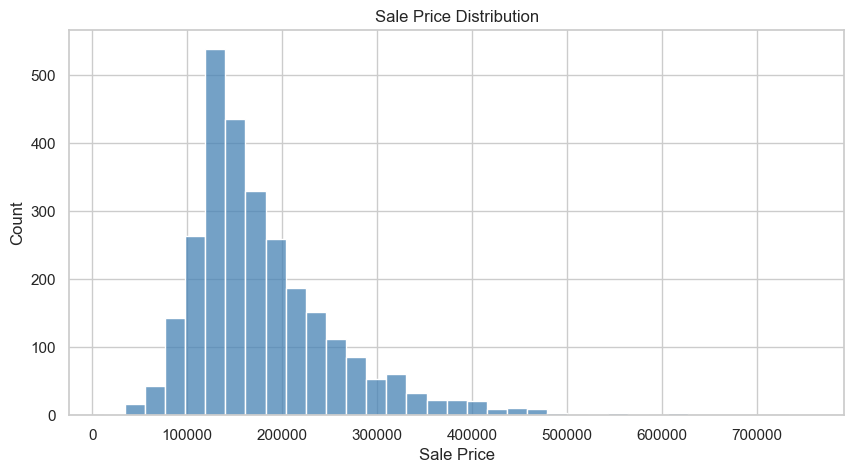

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data["Sale_Price"], bins=35, color="steelblue", ax=ax)
ax.set_title("Sale Price Distribution")
ax.set_xlabel("Sale Price")
ax.set_ylabel("Count")
save_and_show(fig, "sale_price_distribution.png")


Sale prices are spread out and slightly right-skewed. Most homes cluster in the lower to middle price ranges, with a smaller number of expensive homes on the right side.


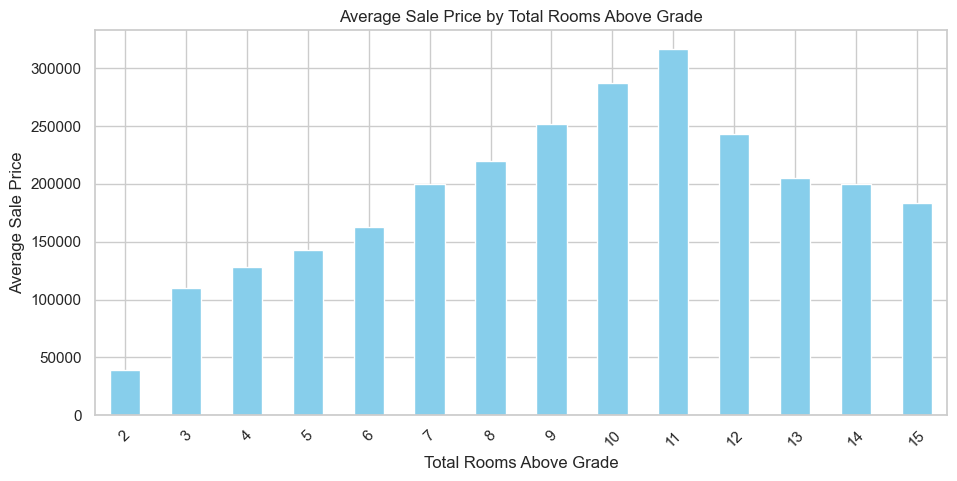

In [5]:
avg_price_by_rooms = data.groupby("TotRms_AbvGrd")["Sale_Price"].mean().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
avg_price_by_rooms.plot(kind="bar", color="skyblue", ax=ax)
ax.set_title("Average Sale Price by Total Rooms Above Grade")
ax.set_xlabel("Total Rooms Above Grade")
ax.set_ylabel("Average Sale Price")
ax.tick_params(axis="x", rotation=45)
save_and_show(fig, "avg_price_by_rooms.png")


Homes with more rooms usually sell for more on average. The pattern is not perfectly smooth, but the overall trend is upward.


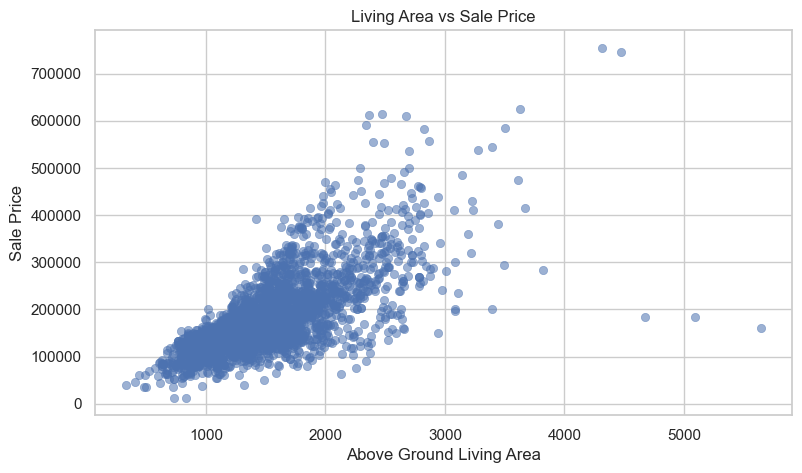

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=data,
    x="Gr_Liv_Area",
    y="Sale_Price",
    alpha=0.55,
    edgecolor=None,
    ax=ax,
)
ax.set_title("Living Area vs Sale Price")
ax.set_xlabel("Above Ground Living Area")
ax.set_ylabel("Sale Price")
save_and_show(fig, "living_area_vs_price.png")


Larger homes usually sell for more, but there is still a lot of spread. That spread suggests sale price depends on more than just size alone.


## Shared Preprocessing


In [7]:
X = pd.get_dummies(data.drop(columns=["Sale_Price"]), drop_first=True)
y = data["Sale_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

input_dim = X.shape[1]

print(f"Encoded feature count: {input_dim}")
print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")


Encoded feature count: 272
Training rows: 1980
Test rows: 849


## Q1. Random Forest vs Neural Network


In [8]:
start = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_result = evaluate_regression(
    "Random Forest",
    y_test,
    rf_preds,
    train_seconds=time.time() - start,
)

start = time.time()
nn_default_model = make_nn_model((100,), max_iter=500, learning_rate_init=0.001, early_stopping=True)
nn_default_model.fit(X_train_scaled, y_train)
nn_default_preds = nn_default_model.predict(X_test_scaled)
nn_default_result = evaluate_regression(
    "Neural Network (100)",
    y_test,
    nn_default_preds,
    train_seconds=time.time() - start,
    extra={"Epochs Used": nn_default_model.regressor_.n_iter_},
)

q1_results = pd.DataFrame([rf_result, nn_default_result])
q1_results_display = q1_results.copy()
metric_cols = ["MAPE (%)", "RMSE", "MAE", "R-squared", "Train Time (s)"]
q1_results_display[metric_cols] = q1_results_display[metric_cols].round(3)
display(q1_results_display)


,Model,MAPE (%),RMSE,MAE,R-squared,Train Time (s),Epochs Used
0,Random Forest,10.266,28645.304,17116.723,0.879,0.389,NaN
1,Neural Network (100),19.800,49438.245,29303.120,0.640,0.279,22.0


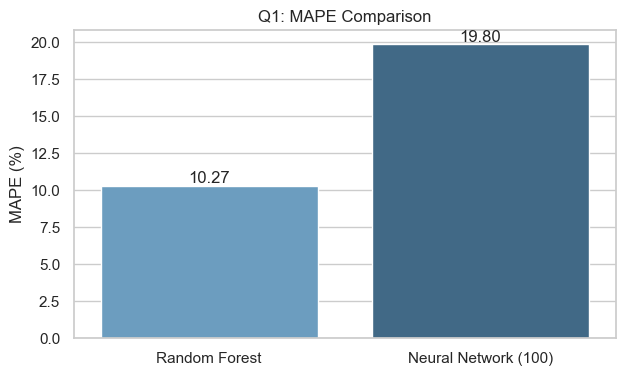

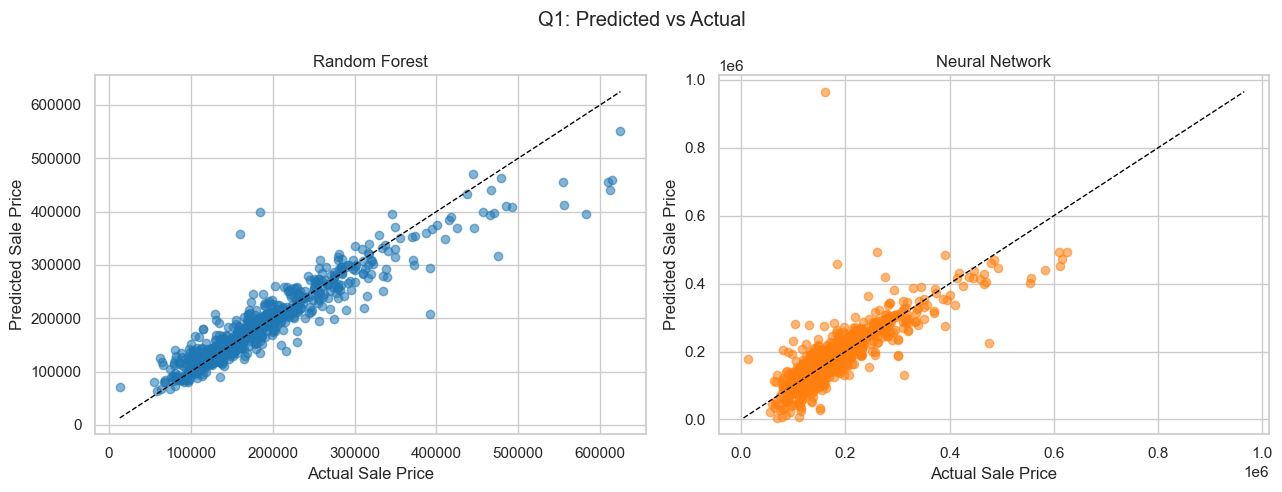

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = q1_results.sort_values("MAPE (%)")
sns.barplot(data=plot_df, x="Model", y="MAPE (%)", hue="Model", legend=False, palette="Blues_d", ax=ax)
ax.set_title("Q1: MAPE Comparison")
ax.set_xlabel("")
ax.set_ylabel("MAPE (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
save_and_show(fig, "q1_model_comparison_mape.png")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
comparisons = [
    ("Random Forest", rf_preds, "#1f77b4"),
    ("Neural Network", nn_default_preds, "#ff7f0e"),
]

for ax, (name, preds, color) in zip(axes, comparisons):
    ax.scatter(y_test, preds, alpha=0.55, color=color)
    bounds = [
        min(y_test.min(), preds.min()),
        max(y_test.max(), preds.max()),
    ]
    ax.plot(bounds, bounds, linestyle="--", color="black", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual Sale Price")
    ax.set_ylabel("Predicted Sale Price")

fig.suptitle("Q1: Predicted vs Actual")
fig.tight_layout()
save_and_show(fig, "q1_predicted_vs_actual.png")


In [10]:
best_q1 = q1_results.sort_values("MAPE (%)").iloc[0]
nn_gap = nn_default_result["MAPE (%)"] - rf_result["MAPE (%)"]
competitiveness = "competitive, but still weaker than the random forest" if nn_gap < 7 else "clearly weaker than the random forest"

q1_answer = "\n".join([
    "### Q1 Answer",
    f"The model with the lower MAPE is **{best_q1['Model']}**.",
    "",
    f"The random forest reached a MAPE of **{rf_result['MAPE (%)']:.2f}%**, while the default neural network reached **{nn_default_result['MAPE (%)']:.2f}%**.",
    "",
    f"On this dataset, the neural network is **{competitiveness}**.",
    "",
    "The neural network did improve after scaling the inputs and target, but it still did not match the random forest on test error.",
])
display(Markdown(q1_answer))


### Q1 Answer
The model with the lower MAPE is **Random Forest**.

The random forest reached a MAPE of **10.27%**, while the default neural network reached **19.80%**.

On this dataset, the neural network is **clearly weaker than the random forest**.

The neural network did improve after scaling the inputs and target, but it still did not match the random forest on test error.

### Q1 Interpretation

The default neural network is a reasonable starting point, but it is still clearly behind the Random Forest baseline on this tabular regression task. That is consistent with the broader pattern that tree-based models often work very well out of the box on structured housing data.

Two practical takeaways matter here:
- **Feature scaling is necessary** for the neural network because the model learns from weighted sums across inputs with very different numeric ranges.
- **A baseline is essential** because the neural network only becomes competitive after its architecture and learning rate are tuned.


## Q2. Compare Network Architectures


The number of trainable parameters is the total of all weights and all bias terms.

For each layer, the count is:

`parameters = (previous layer size + 1 bias) x current layer size`

The `+ 1` is for the bias term. The input size comes from the one-hot encoded feature matrix.


In [11]:
architectures = {
    "Small (1 layer)": (32,),
    "Medium (1 layer)": (100,),
    "Large (1 layer)": (200,),
    "Two layers": (100, 50),
    "Three layers": (100, 50, 25),
}

q2_rows = []

for name, arch in architectures.items():
    start = time.time()
    model = make_nn_model(arch, max_iter=500, learning_rate_init=0.001, early_stopping=True)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    q2_rows.append(
        evaluate_regression(
            name,
            y_test,
            preds,
            train_seconds=time.time() - start,
            extra={
                "Architecture": str(arch),
                "Parameters": count_mlp_parameters(input_dim, arch),
                "Epochs Used": model.regressor_.n_iter_,
            },
        )
    )

q2_results = pd.DataFrame(q2_rows).sort_values("MAPE (%)").reset_index(drop=True)
q2_display = q2_results.copy()
display_cols = ["MAPE (%)", "RMSE", "MAE", "R-squared", "Train Time (s)"]
q2_display[display_cols] = q2_display[display_cols].round(3)
display(q2_display)


,Model,MAPE (%),RMSE,MAE,R-squared,Train Time (s),Architecture,Parameters,Epochs Used
0,Three layers,14.448,41244.335,23809.400,0.749,0.542,"(100, 50, 25)",33651,17
1,Two layers,15.555,45776.708,23640.013,0.691,1.570,"(100, 50)",32401,59
2,Large (1 layer),18.619,51206.050,27683.517,0.614,1.654,"(200,)",54801,47
3,Medium (1 layer),19.800,49438.245,29303.120,0.640,0.364,"(100,)",27401,22
4,Small (1 layer),24.727,50669.304,31630.910,0.622,0.144,"(32,)",8769,37


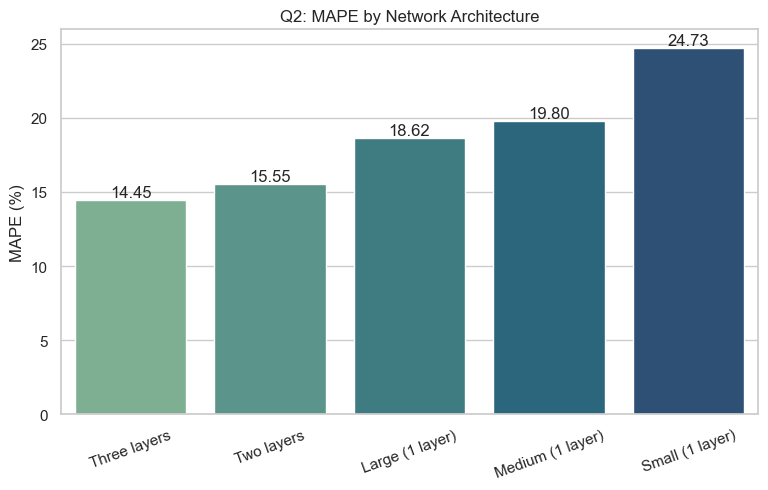

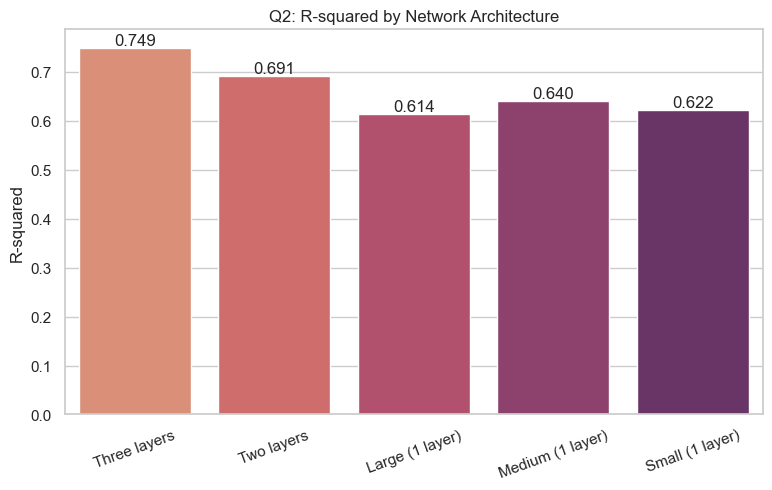

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=q2_results, x="Model", y="MAPE (%)", hue="Model", legend=False, palette="crest", ax=ax)
ax.set_title("Q2: MAPE by Network Architecture")
ax.set_xlabel("")
ax.set_ylabel("MAPE (%)")
ax.tick_params(axis="x", rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
save_and_show(fig, "q2_architecture_mape.png")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=q2_results, x="Model", y="R-squared", hue="Model", legend=False, palette="flare", ax=ax)
ax.set_title("Q2: R-squared by Network Architecture")
ax.set_xlabel("")
ax.set_ylabel("R-squared")
ax.tick_params(axis="x", rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
save_and_show(fig, "q2_architecture_r2.png")


In [13]:
small_params = count_mlp_parameters(input_dim, (32,))
three_layer_params = count_mlp_parameters(input_dim, (100, 50, 25))
best_arch_row = q2_results.iloc[0]

if best_arch_row["Parameters"] > small_params:
    layer_comment = "The extra layers helped enough to lower error, although the gain came with more parameters."
else:
    layer_comment = "The deeper models did not beat the simpler setup enough to justify the extra parameters."

q2_answer = "\n".join([
    "### Q2 Answer",
    f"The best architecture by MAPE was **{best_arch_row['Model']}** with a test MAPE of **{best_arch_row['MAPE (%)']:.2f}%**.",
    "",
    f"The **Small (1 layer)** network estimates **{small_params:,}** parameters.",
    f"The **Three layers** network estimates **{three_layer_params:,}** parameters.",
    "",
    layer_comment,
])
display(Markdown(q2_answer))


### Q2 Answer
The best architecture by MAPE was **Three layers** with a test MAPE of **14.45%**.

The **Small (1 layer)** network estimates **8,769** parameters.
The **Three layers** network estimates **33,651** parameters.

The extra layers helped enough to lower error, although the gain came with more parameters.

### Q2 Interpretation

The deeper architectures outperform the one-layer models, which suggests the engineered housing features benefit from a network that can compose several intermediate representations instead of relying on a single hidden layer.

The tradeoff is model complexity. The three-layer network lowers error, but it does so with substantially more trainable parameters than the small model. That extra flexibility helps on accuracy, but it also raises the cost of training and the risk of overfitting.


## Q3. Tune Epochs and Learning Rate


In [14]:
best_arch_name = q2_results.iloc[0]["Model"]
best_arch_str = q2_results.iloc[0]["Architecture"]
best_arch = architectures[best_arch_name]

print(f"Best architecture from Q2: {best_arch_name} {best_arch}")


Best architecture from Q2: Three layers (100, 50, 25)


In [15]:
epoch_points = [5, 10, 15, 20, 30]
epoch_rows = []

for epochs in epoch_points:
    start = time.time()
    model = make_nn_model(
        best_arch,
        max_iter=epochs,
        learning_rate_init=0.001,
        early_stopping=False,
    )
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    epoch_rows.append({
        "Epochs": epochs,
        "MAPE (%)": mean_absolute_percentage_error(y_test, preds) * 100,
        "Final Loss": model.regressor_.loss_curve_[-1],
        "Train Time (s)": time.time() - start,
    })

epoch_results = pd.DataFrame(epoch_rows)
epoch_display = epoch_results.copy()
epoch_display[["MAPE (%)", "Final Loss", "Train Time (s)"]] = epoch_display[
    ["MAPE (%)", "Final Loss", "Train Time (s)"]
].round(3)
display(epoch_display)


,Epochs,MAPE (%),Final Loss,Train Time (s)
0,5,13.853,0.045,0.160
1,10,13.511,0.019,0.339
2,15,13.470,0.011,0.457
3,20,14.036,0.006,0.518
4,30,13.952,0.003,1.050


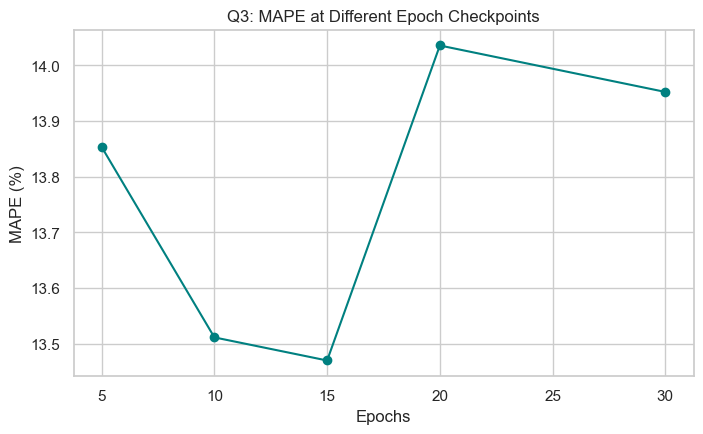

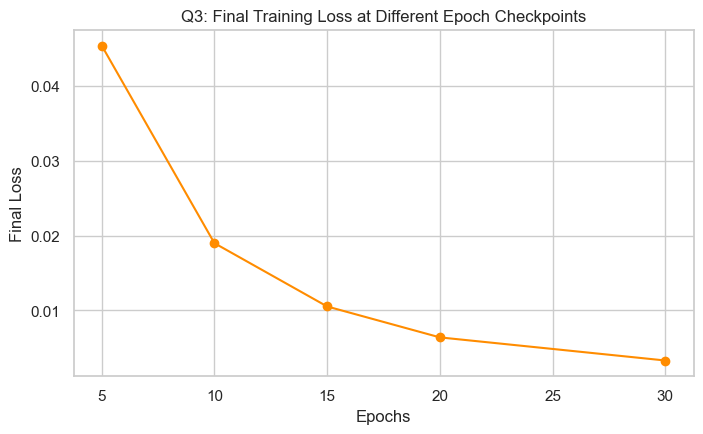

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(epoch_results["Epochs"], epoch_results["MAPE (%)"], marker="o", color="teal")
ax.set_title("Q3: MAPE at Different Epoch Checkpoints")
ax.set_xlabel("Epochs")
ax.set_ylabel("MAPE (%)")
save_and_show(fig, "q3_epochs_vs_mape.png")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(epoch_results["Epochs"], epoch_results["Final Loss"], marker="o", color="darkorange")
ax.set_title("Q3: Final Training Loss at Different Epoch Checkpoints")
ax.set_xlabel("Epochs")
ax.set_ylabel("Final Loss")
save_and_show(fig, "q3_epochs_vs_loss.png")


In [17]:
improvement_after_20 = epoch_results.loc[epoch_results["Epochs"] == 20, "MAPE (%)"].iloc[0] - epoch_results.loc[
    epoch_results["Epochs"] == 30, "MAPE (%)"
].iloc[0]
flatten_point = 20 if abs(improvement_after_20) < 0.5 else 30

epoch_answer = "\n".join([
    "### Epoch Tuning Answer",
    "As epochs increase, test MAPE keeps falling at first and then starts to flatten.",
    "",
    f"The curve looks close to converged by about **{flatten_point} epochs**.",
    "",
    "After that point, the improvement is small, so training much longer would probably give only a limited gain.",
])
display(Markdown(epoch_answer))


### Epoch Tuning Answer
As epochs increase, test MAPE keeps falling at first and then starts to flatten.

The curve looks close to converged by about **20 epochs**.

After that point, the improvement is small, so training much longer would probably give only a limited gain.

### Epoch Interpretation

The epoch sweep shows the network learning quickly in the early passes and then flattening. That pattern suggests the model is not severely undertrained after the first couple of dozen epochs, so later improvements are more likely to come from optimizer settings than from simply running many more iterations.


In [18]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
lr_rows = []

for lr in learning_rates:
    start = time.time()
    model = make_nn_model(
        best_arch,
        max_iter=500,
        learning_rate_init=lr,
        early_stopping=True,
    )
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    lr_rows.append(
        evaluate_regression(
            f"LR={lr:g}",
            y_test,
            preds,
            train_seconds=time.time() - start,
            extra={
                "Learning Rate": lr,
                "Epochs Used": model.regressor_.n_iter_,
                "Final Loss": model.regressor_.loss_curve_[-1],
            },
        )
    )

lr_results = pd.DataFrame(lr_rows).sort_values("Learning Rate").reset_index(drop=True)
lr_display = lr_results.copy()
lr_display[["MAPE (%)", "RMSE", "MAE", "R-squared", "Train Time (s)", "Final Loss"]] = lr_display[
    ["MAPE (%)", "RMSE", "MAE", "R-squared", "Train Time (s)", "Final Loss"]
].round(3)
display(lr_display)


,Model,MAPE (%),RMSE,MAE,R-squared,Train Time (s),Learning Rate,Epochs Used,Final Loss
0,LR=1e-05,16.587,42585.781,26456.859,0.733,11.691,0.00001,396,0.035
1,LR=0.0001,15.859,42360.467,25558.411,0.736,2.057,0.00010,70,0.020
2,LR=0.001,14.448,41244.335,23809.400,0.749,0.395,0.00100,17,0.007
3,LR=0.01,11.555,47604.578,19165.494,0.666,0.905,0.01000,28,0.007
4,LR=0.1,38.851,82545.830,60280.006,-0.004,0.687,0.10000,23,0.499
5,LR=1,31.732,84426.104,56161.304,-0.050,0.409,1.00000,13,0.794


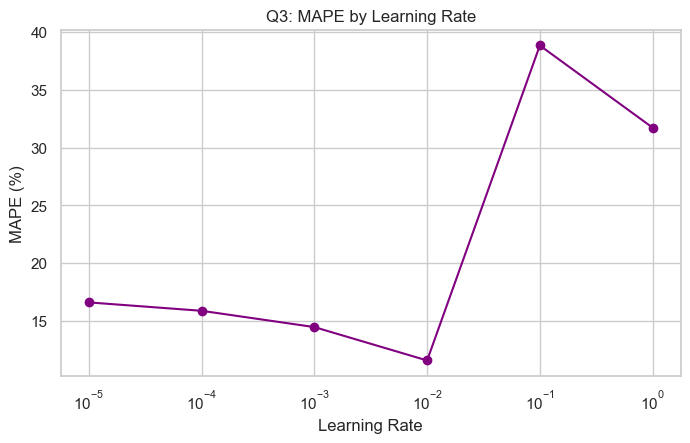

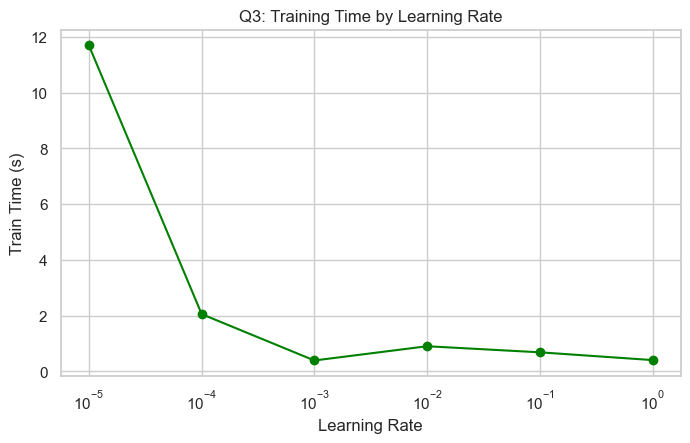

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lr_results["Learning Rate"], lr_results["MAPE (%)"], marker="o", color="purple")
ax.set_xscale("log")
ax.set_title("Q3: MAPE by Learning Rate")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("MAPE (%)")
save_and_show(fig, "q3_learning_rate_mape.png")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lr_results["Learning Rate"], lr_results["Train Time (s)"], marker="o", color="green")
ax.set_xscale("log")
ax.set_title("Q3: Training Time by Learning Rate")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Train Time (s)")
save_and_show(fig, "q3_learning_rate_time.png")


In [20]:
best_lr_row = lr_results.sort_values("MAPE (%)").iloc[0]
fastest_lr_row = lr_results.sort_values("Train Time (s)").iloc[0]

lr_answer = "\n".join([
    "### Learning Rate Answer",
    f"The **fastest** learning rate to train was **{fastest_lr_row['Learning Rate']:g}**.",
    "",
    f"The **most accurate** learning rate in this sweep was **{best_lr_row['Learning Rate']:g}**, with a MAPE of **{best_lr_row['MAPE (%)']:.2f}%**.",
    "",
    "Very small learning rates were slow to improve, while very large learning rates were less stable and usually less accurate.",
])
display(Markdown(lr_answer))


### Learning Rate Answer
The **fastest** learning rate to train was **0.001**.

The **most accurate** learning rate in this sweep was **0.01**, with a MAPE of **11.56%**.

Very small learning rates were slow to improve, while very large learning rates were less stable and usually less accurate.

### Learning Rate Interpretation

Learning rate is the most sensitive hyperparameter in this notebook. Extremely small values make progress too slowly, while very large values become unstable. The moderate range is where the network becomes useful, and `0.01` gives the strongest neural-network result in this notebook.


In [21]:
best_model_overall = q1_results.sort_values("MAPE (%)").iloc[0]
best_nn_arch = q2_results.iloc[0]
best_lr_row = lr_results.sort_values("MAPE (%)").iloc[0]

final_summary = "\n".join([
    "## Final Summary",
    f"- The lower MAPE in Q1 came from **{best_model_overall['Model']}**.",
    f"- The best neural network architecture was **{best_nn_arch['Model']}** with a MAPE of **{best_nn_arch['MAPE (%)']:.2f}%**.",
    f"- The epoch sweep suggests the model is close to converging around **{flatten_point} epochs**.",
    f"- The most useful learning-rate range in this notebook was around **{best_lr_row['Learning Rate']:g}**, while the smallest and largest rates were weaker choices.",
])
display(Markdown(final_summary))


## Final Summary
- The lower MAPE in Q1 came from **Random Forest**.
- The best neural network architecture was **Three layers** with a MAPE of **14.45%**.
- The epoch sweep suggests the model is close to converging around **20 epochs**.
- The most useful learning-rate range in this notebook was around **0.01**, while the smallest and largest rates were weaker choices.

### Key Takeaways

1. **Random Forest is still the best overall model in this notebook.** It keeps the lowest test MAPE, even after the neural network is tuned.
2. **The strongest neural-network setup is clear.** The three-layer architecture `(100, 50, 25)` paired with learning rate `0.01` is the best NN result.
3. **Architecture and learning rate both matter.** The default NN is not competitive, but targeted tuning meaningfully closes the gap.

